# Minimarket POS — Beginner Analytics

Connects directly to the ClickHouse data warehouse and answers the three
Beginner analytic questions using the dbt star schema (`analytics.*`).
Single-tenant scope: `tenant_01`.

| Q | Question | Chart |
|---|----------|-------|
| Q1 | Top 5 products per category (by quantity) | grouped horizontal bar |
| Q2 | Monthly revenue trend | line chart |
| Q3 | Payment method distribution | donut chart |

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import clickhouse_connect

TENANT = os.getenv('BEGINNER_TENANT', 'tenant_01')

client = clickhouse_connect.get_client(
    host=os.getenv('CLICKHOUSE_HOST', 'localhost'),
    port=int(os.getenv('CLICKHOUSE_HTTP_PORT', '8123')),
    username=os.getenv('CLICKHOUSE_USER', 'default'),
    password=os.getenv('CLICKHOUSE_PASSWORD', 'clickhouse'),
)

def q(sql):
    return client.query_df(sql)

print('connected; tenant =', TENANT)

/Users/damaradi/Documents/personal/interview/parkee/parkee-de-test/analytics/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


connected; tenant = tenant_01


## Q1 — Top 5 products per category (by total quantity sold)

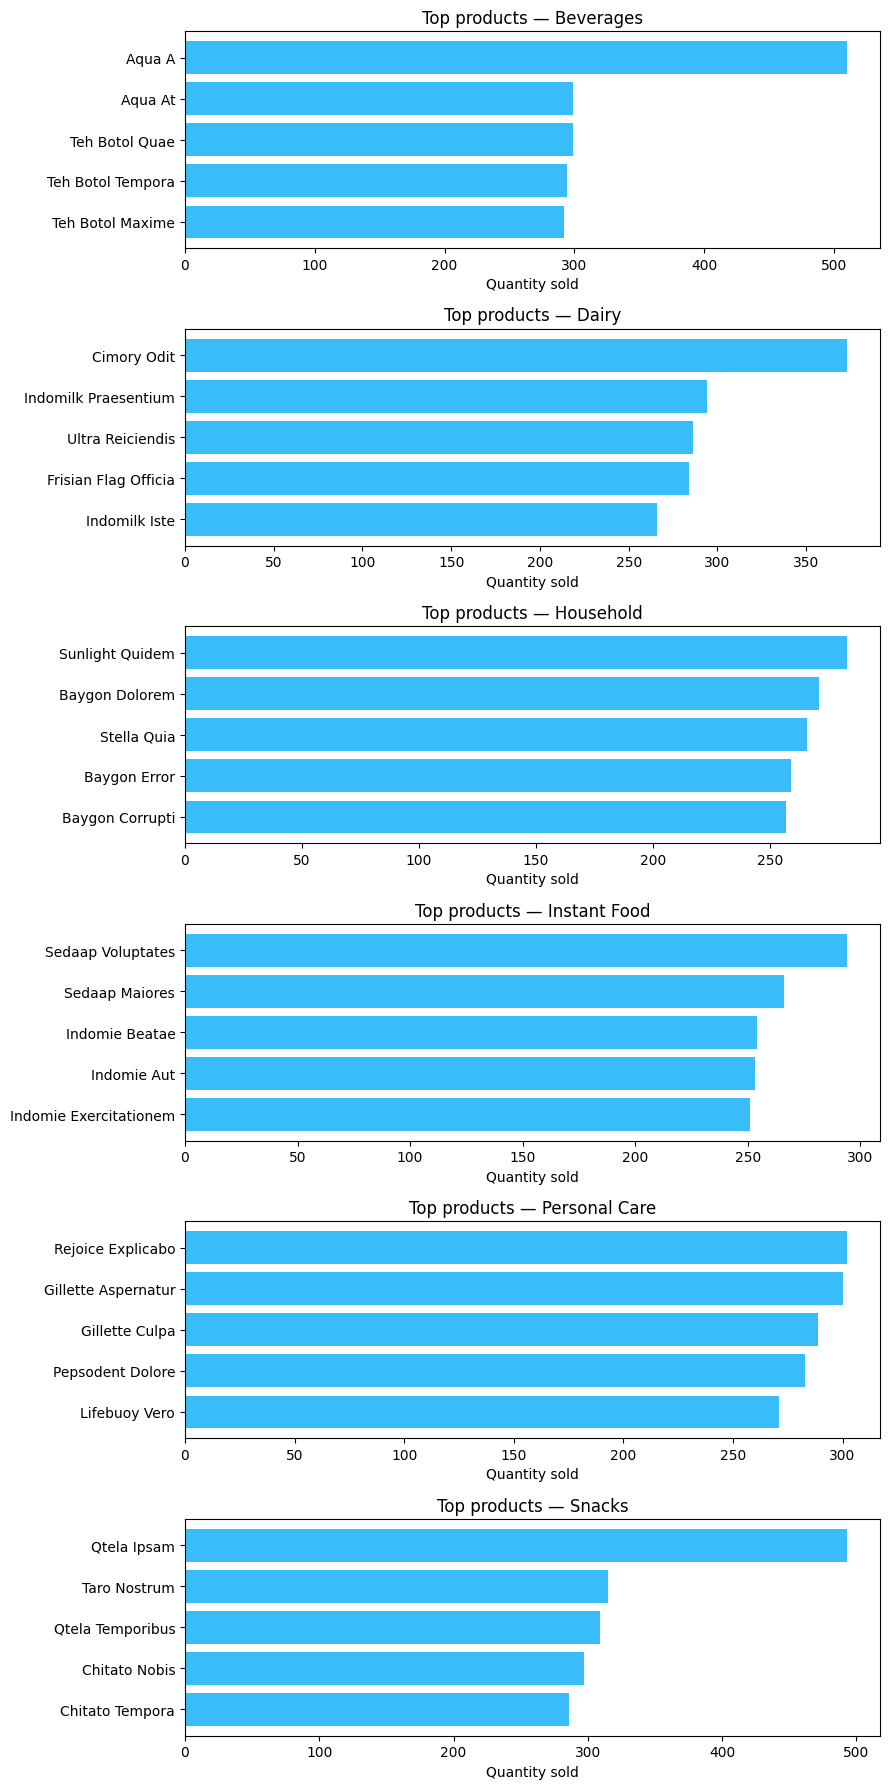

,category,product_name,qty
0,Beverages,Aqua A,510
1,Beverages,Teh Botol Quae,299
2,Beverages,Aqua At,299
3,Beverages,Teh Botol Tempora,294
4,Beverages,Teh Botol Maxime,292
5,Dairy,Cimory Odit,373
6,Dairy,Indomilk Praesentium,294
7,Dairy,Ultra Reiciendis,286
8,Dairy,Frisian Flag Officia,284
9,Dairy,Indomilk Iste,266


In [2]:
sql_q1 = f"""
SELECT category, product_name, qty FROM (
    SELECT p.category AS category, p.product_name AS product_name,
           sum(f.quantity) AS qty,
           row_number() OVER (PARTITION BY p.category ORDER BY sum(f.quantity) DESC) AS rn
    FROM analytics.fact_sales AS f
    JOIN analytics.dim_product AS p ON f.product_sk = p.product_sk
    WHERE f.tenant_id = '{TENANT}'
    GROUP BY category, product_name
) WHERE rn <= 5
ORDER BY category, qty DESC
"""
df1 = q(sql_q1)

categories = df1['category'].unique()
fig, axes = plt.subplots(len(categories), 1, figsize=(9, 3 * len(categories)))
if len(categories) == 1:
    axes = [axes]
for ax, cat in zip(axes, categories):
    sub = df1[df1['category'] == cat].sort_values('qty')
    ax.barh(sub['product_name'], sub['qty'], color='#38bdf8')
    ax.set_title(f'Top products — {cat}')
    ax.set_xlabel('Quantity sold')
fig.tight_layout()
plt.show()
df1.head(15)

## Q2 — Monthly revenue trend

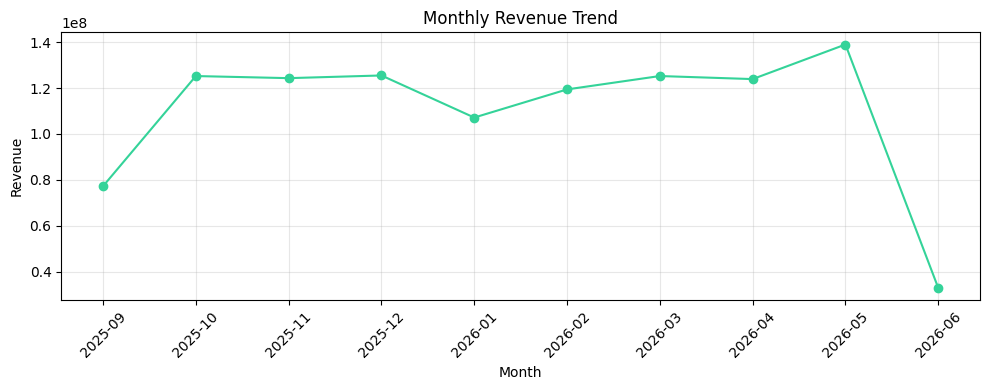

,year_month,revenue
0,2025-09,7.724121e+07
1,2025-10,1.252087e+08
2,2025-11,1.242951e+08
3,2025-12,1.254646e+08
4,2026-01,1.071334e+08
5,2026-02,1.193904e+08
6,2026-03,1.252162e+08
7,2026-04,1.238854e+08
8,2026-05,1.389470e+08
9,2026-06,3.294449e+07


In [3]:
sql_q2 = f"""
SELECT d.year_month AS year_month, round(sum(f.net_amount), 2) AS revenue
FROM analytics.fact_sales AS f
JOIN analytics.dim_date AS d ON f.date_key = d.date_key
WHERE f.tenant_id = '{TENANT}'
GROUP BY year_month
ORDER BY year_month
"""
df2 = q(sql_q2)

plt.figure(figsize=(10, 4))
plt.plot(df2['year_month'], df2['revenue'], marker='o', color='#34d399')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month'); plt.ylabel('Revenue')
plt.xticks(rotation=45); plt.grid(alpha=.3); plt.tight_layout()
plt.show()
df2

## Q3 — Payment method distribution

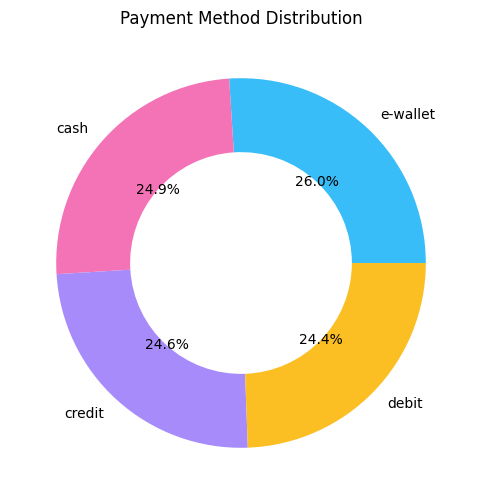

,payment_method,transactions,pct
0,e-wallet,743,26.0
1,cash,712,24.9
2,credit,703,24.6
3,debit,697,24.4


In [4]:
sql_q3 = f"""
SELECT payment_method, count(DISTINCT transaction_sk) AS transactions
FROM analytics.fact_sales
WHERE tenant_id = '{TENANT}'
GROUP BY payment_method
ORDER BY transactions DESC
"""
df3 = q(sql_q3)
df3['pct'] = (df3['transactions'] / df3['transactions'].sum() * 100).round(1)

plt.figure(figsize=(6, 6))
plt.pie(df3['transactions'], labels=df3['payment_method'], autopct='%1.1f%%',
        wedgeprops=dict(width=0.4),
        colors=['#38bdf8', '#f472b6', '#a78bfa', '#fbbf24', '#34d399'])
plt.title('Payment Method Distribution')
plt.show()
df3